In [8]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_
from train_functions import train_epochs, valid
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


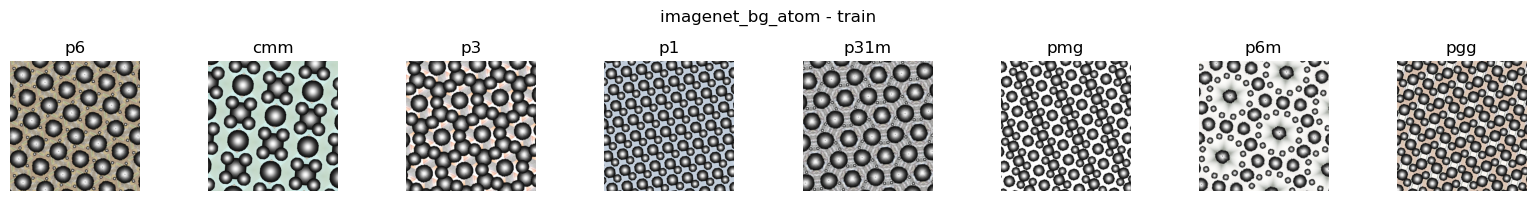

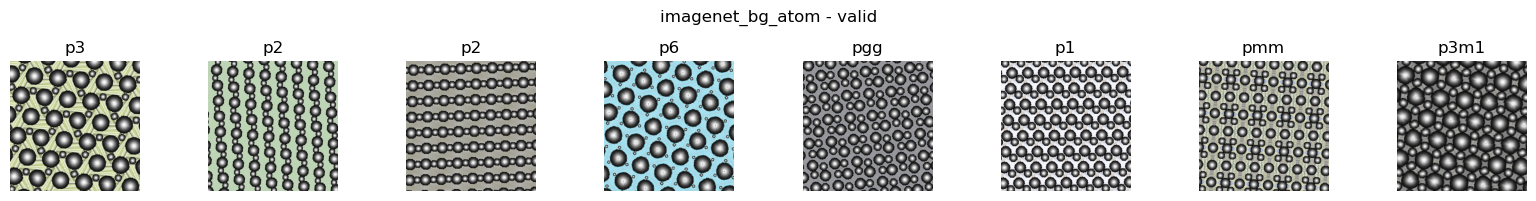

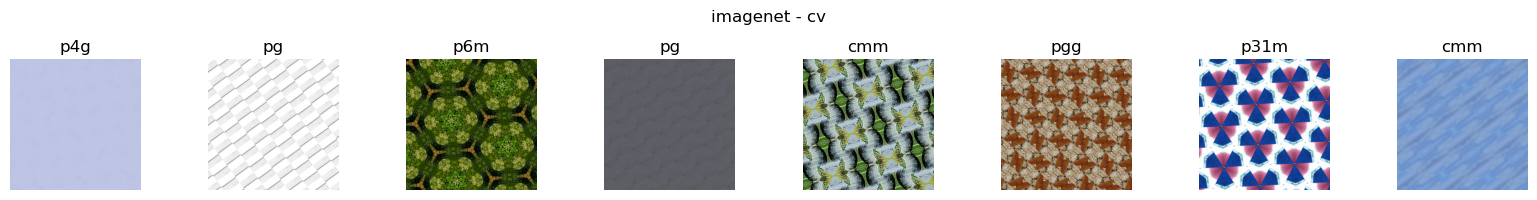

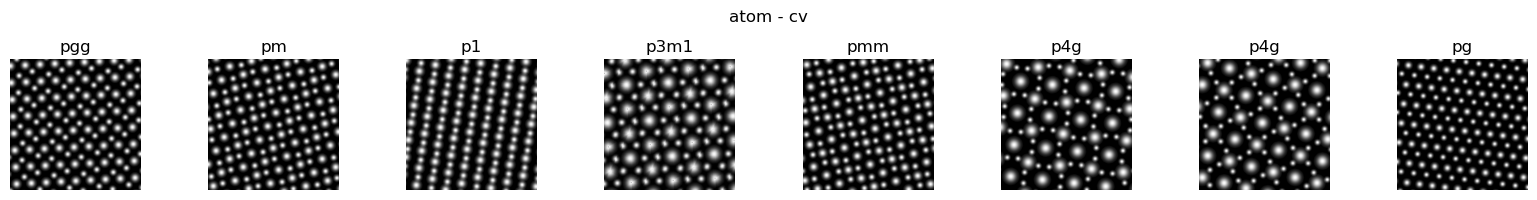

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 1000

# imagenet_bg_atom
imagenet_bg_atom_ds = hdf5_dataset('../../../../imagenet_bg_atom_v5_1m.h5', folder='imagenet_bg_atom', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_bg_atom_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=3)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet_bg_atom - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=3)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet_bg_atom - valid')

# imagenet_ds
imagenet_ds = hdf5_dataset('../../../../imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.9)
imagenet_dl = DataLoader(imagenet_ds, batch_size=bs, shuffle=False, num_workers=3)
viz_dataloader(imagenet_dl, label_converter=label_converter, title='imagenet - cv')

# atom
atom_ds = hdf5_dataset('../../../../atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=False, num_workers=3)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

In [3]:
config = {
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '06132024-benchmark-resnet50_from_scratch-imagenet_bg_atom_v5_1m'

# train

In [4]:
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [5]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[0,5,6])
# model

torch.Size([2, 17])


In [6]:
device = torch.device('cuda:0')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl_list=[valid_dl, imagenet_dl, atom_dl], 
                       valid_name_list=['validation', 'imagenet_cv', 'atom_cv'], epochs=epochs, start=start, scheduler=scheduler,
                       valid_every_epochs=5, model_dir='../../../saved_models/06132024-benchmark-ResNet50-imagenet_bg_atom_v5_1m/', tracking=True)

Epoch: 1/20


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 980/980 [18:36<00:00,  1.14s/it]


Training: Loss: 1.8855, Accuracy: 34.6492%.
Epoch: 2/20


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 980/980 [19:23<00:00,  1.19s/it]


Training: Loss: 0.9668, Accuracy: 63.8317%.
Epoch: 3/20


...

validation: Loss: 0.0400, Accuracy: 98.4980%.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1072/1072 [15:54<00:00,  1.12it/s]


imagenet_cv, atom_cv: Loss: 5.1414, Accuracy: 15.6863%.
Epoch: 6/20


 14%|█████████████████▎                                                                                                         | 138/980 [03:03<18:40,  1.33s/it]


KeyboardInterrupt: 

In [9]:
device = torch.device('cuda:0')
loss_func = nn.CrossEntropyLoss()
  
avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, imagenet_dl, task_label='cv_atom', tracking=False)
print(f"imagenet_cv: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, atom_dl, task_label='cv_noise', tracking=False)
print(f"atom_cv: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1072/1072 [15:55<00:00,  1.12it/s]


imagenet_cv: Loss: 5.7056, Accuracy: 15.4870%.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 204/204 [02:52<00:00,  1.18it/s]

atom_cv: Loss: 5.6960, Accuracy: 9.3358%.


In [10]:
device = torch.device('cuda:0')
lr = 1e-3
start = 5
epochs = 5

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl_list=[valid_dl, imagenet_dl, atom_dl], 
                       valid_name_list=['validation', 'imagenet_cv', 'atom_cv'], epochs=epochs, start=start, scheduler=scheduler,
                       valid_every_epochs=5, model_dir='../../../saved_models/06132024-benchmark-ResNet50-imagenet_bg_atom_v5_1m/', tracking=True)

Epoch: 6/10


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 980/980 [18:34<00:00,  1.14s/it]


Training: Loss: 0.0354, Accuracy: 98.6825%.
Epoch: 7/10


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 980/980 [18:21<00:00,  1.12s/it]


Training: Loss: 0.0953, Accuracy: 96.9625%.
Epoch: 8/10


...

validation: Loss: 0.0128, Accuracy: 99.4657%.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1072/1072 [17:29<00:00,  1.02it/s]


imagenet_cv: Loss: 5.7900, Accuracy: 19.4361%.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 204/204 [03:16<00:00,  1.04it/s]


atom_cv: Loss: 11.6255, Accuracy: 6.8608%.
